# Week 2: Digital Health and AI Fundamentals
## Course: Digital Health and AI in Medical Applications (BME 7451)
### Instructor: Prof. Che-Wei Lin, NCKU BME

---

**Learning Objectives:**
1. Define digital health and identify its key technology domains
2. Distinguish between AI, Machine Learning, and Deep Learning
3. Explain fundamental ML concepts: features, labels, training, loss, metrics
4. Train and evaluate a simple classifier on a medical dataset

**Tools:** Google Colab + Gemini AI
**Dataset:** Breast Cancer Wisconsin (Diagnostic) — `sklearn` built-in
**Estimated Time:** 40-50 minutes

---


## 0. Environment Setup

All libraries used in this notebook are pre-installed in Google Colab. No additional installation needed!


In [1]:
# ============================================================
# Section 0: Environment Setup
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ All libraries loaded successfully!")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")


✅ All libraries loaded successfully!
NumPy: 2.0.2
Pandas: 2.2.2


## 1. Load & Inspect the Patient Data

The **Breast Cancer Wisconsin (Diagnostic)** dataset contains measurements from **Fine Needle Aspiration (FNA)** biopsies of breast masses. Each row represents one patient, and each column is a measurement of cell nuclei characteristics.

**Clinical Context:** A surgeon performs FNA, sends the sample to a pathologist who measures 30 features of cell nuclei under a microscope. Can we train AI to classify tumors as malignant or benign based on these measurements?


In [2]:
# ============================================================
# Section 1: Load the Breast Cancer Dataset
# ============================================================
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='diagnosis')

print(f"📊 Dataset shape: {X.shape}")
print(f"   → {X.shape[0]} patients, {X.shape[1]} features\n")
print(f"🔬 First 5 features: {list(X.columns[:5])}\n")
print(f"📋 Target classes:")
print(f"   → Malignant (0): {sum(y==0)} patients ({sum(y==0)/len(y)*100:.1f}%)")
print(f"   → Benign (1):    {sum(y==1)} patients ({sum(y==1)/len(y)*100:.1f}%)")


📊 Dataset shape: (569, 30)
   → 569 patients, 30 features

🔬 First 5 features: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']

📋 Target classes:
   → Malignant (0): 212 patients (37.3%)
   → Benign (1):    357 patients (62.7%)


In [3]:
# Quick look at the data
print("\n📈 Feature statistics (first 5 features):")
display(X.iloc[:, :5].describe().round(2))



📈 Feature statistics (first 5 features):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness
count,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10
std,3.52,4.30,24.30,351.91,0.01
min,6.98,9.71,43.79,143.50,0.05
25%,11.70,16.17,75.17,420.30,0.09
50%,13.37,18.84,86.24,551.10,0.10
75%,15.78,21.80,104.10,782.70,0.11
max,28.11,39.28,188.50,2501.00,0.16


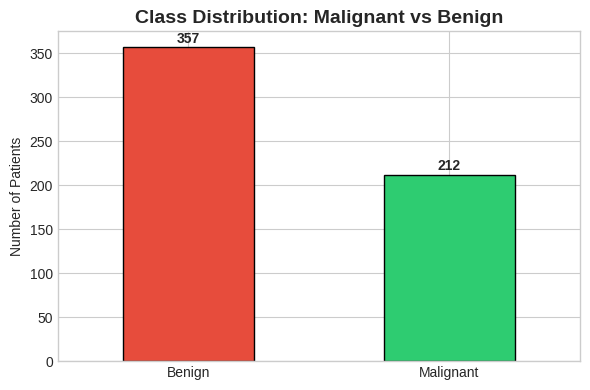

⚠️ Note: The dataset is slightly imbalanced (63% benign vs 37% malignant)


In [4]:
# Visualize class distribution
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#E74C3C', '#2ECC71']
y.map({0: 'Malignant', 1: 'Benign'}).value_counts().plot(
    kind='bar', color=colors, edgecolor='black', ax=ax)
ax.set_title('Class Distribution: Malignant vs Benign', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Patients')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(y.map({0: 'Malignant', 1: 'Benign'}).value_counts()):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print("⚠️ Note: The dataset is slightly imbalanced (63% benign vs 37% malignant)")


## 2. Exploratory Data Analysis (EDA)

Before training any model, we must **understand the data** — just like a pathologist examines slides before making a diagnosis.

**Key questions:**
- Which features are most correlated with the target (malignant/benign)?
- Are there redundant features (highly correlated with each other)?
- How do feature distributions differ between malignant and benign tumors?


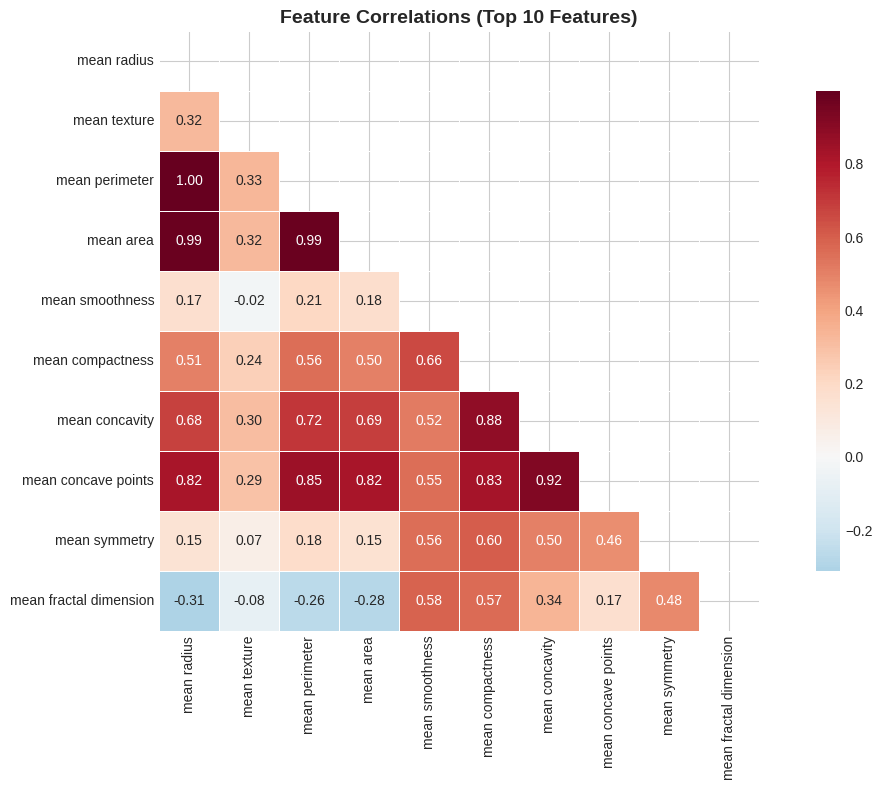

💡 Highly correlated features (>0.9) may be redundant.
   Example: 'mean radius' and 'mean perimeter' are almost perfectly correlated.


In [6]:
# ============================================================
# Section 2a: Correlation Heatmap
# ============================================================
# Focus on first 10 features for readability
plt.figure(figsize=(12, 8))
corr_matrix = X.iloc[:, :10].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlations (Top 10 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 Highly correlated features (>0.9) may be redundant.")
print("   Example: 'mean radius' and 'mean perimeter' are almost perfectly correlated.")


In [7]:
# ============================================================
# Section 2b: Top 5 Discriminative Features
# ============================================================
# Find features most correlated with the target
df_full = X.copy()
df_full['target'] = y
correlations = df_full.corr()['target'].drop('target').abs().sort_values(ascending=False)
top5_features = correlations.head(5).index.tolist()

print("🏆 Top 5 features most correlated with diagnosis:")
for i, feat in enumerate(top5_features, 1):
    print(f"   {i}. {feat}: |r| = {correlations[feat]:.3f}")


🏆 Top 5 features most correlated with diagnosis:
   1. worst concave points: |r| = 0.794
   2. worst perimeter: |r| = 0.783
   3. mean concave points: |r| = 0.777
   4. worst radius: |r| = 0.776
   5. mean perimeter: |r| = 0.743


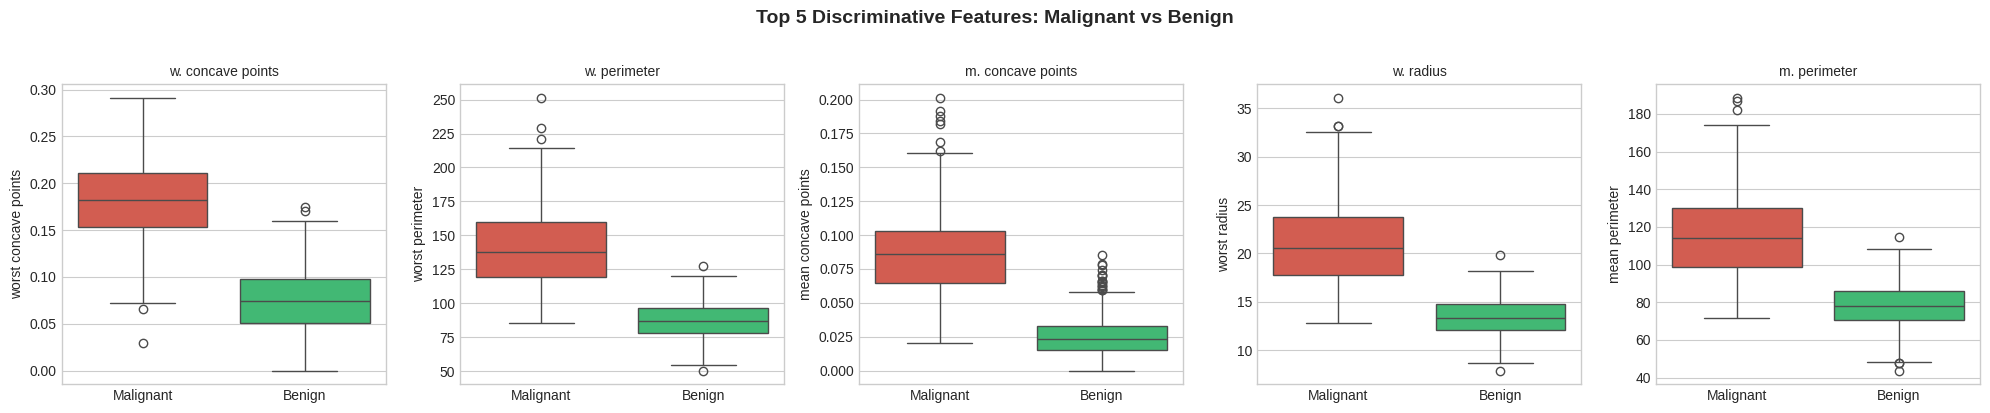

💡 Notice how malignant tumors tend to have LARGER values for these features.
   This makes biological sense — malignant cells are typically larger and more irregular.


In [8]:
# ============================================================
# Section 2c: Box Plots for Top 5 Features
# ============================================================
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, feat in enumerate(top5_features):
    df_plot = pd.DataFrame({feat: X[feat], 'Diagnosis': y.map({0: 'Malignant', 1: 'Benign'})})
    sns.boxplot(data=df_plot, x='Diagnosis', y=feat, ax=axes[i],
                palette={'Malignant': '#E74C3C', 'Benign': '#2ECC71'})
    axes[i].set_title(feat.replace('worst ', 'w. ').replace('mean ', 'm. '), fontsize=10)
    axes[i].set_xlabel('')

fig.suptitle('Top 5 Discriminative Features: Malignant vs Benign', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("💡 Notice how malignant tumors tend to have LARGER values for these features.")
print("   This makes biological sense — malignant cells are typically larger and more irregular.")


## 3. Your First Classifier: Logistic Regression

Now we train our first ML model! **Logistic Regression** is a simple but powerful algorithm for binary classification.

**Clinical framing:**
- `train_test_split` → Hold out 20% of patients as "new patients the model has never seen"
- `model.fit()` → The AI is learning from 455 labeled cases
- `model.predict()` → Diagnosing 114 new patients
- `classification_report` → Sensitivity, specificity, PPV in one table


In [9]:
# ============================================================
# Section 3: Train Logistic Regression Classifier
# ============================================================

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} patients")
print(f"Test set:     {X_test.shape[0]} patients")
print(f"  → Malignant in test: {sum(y_test==0)}")
print(f"  → Benign in test:    {sum(y_test==1)}")

# Train logistic regression
model_lr = LogisticRegression(max_iter=10000, random_state=42)
model_lr.fit(X_train, y_train)

# Predict
y_pred_lr = model_lr.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred_lr)
print(f"\n🎯 Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"\n📊 Classification Report:")
print(classification_report(y_test, y_pred_lr,
      target_names=['Malignant', 'Benign']))


Training set: 455 patients
Test set:     114 patients
  → Malignant in test: 42
  → Benign in test:    72

🎯 Accuracy: 0.965 (96.5%)

📊 Classification Report:
              precision    recall  f1-score   support

   Malignant       0.97      0.93      0.95        42
      Benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



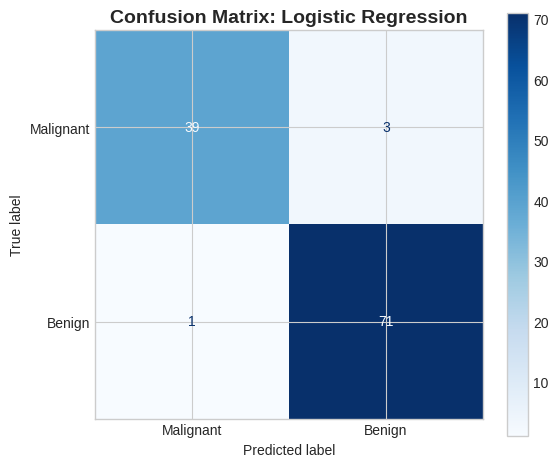


🏥 Clinical Interpretation:
   True Positives (correctly identified benign):  71
   True Negatives (correctly identified malignant): 39
   False Positives (benign misclassified as malignant): 3
   False Negatives (malignant MISSED as benign):   1

   ⚠️ 1 malignant tumors were MISSED — these patients would not receive treatment!
   Sensitivity for malignant class: 0.929


In [10]:
# ============================================================
# Section 3b: Confusion Matrix Visualization
# ============================================================
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(cm, display_labels=['Malignant', 'Benign'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix: Logistic Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Interpret results clinically
tn, fp, fn, tp = cm.ravel()
print(f"\n🏥 Clinical Interpretation:")
print(f"   True Positives (correctly identified benign):  {tp}")
print(f"   True Negatives (correctly identified malignant): {tn}")
print(f"   False Positives (benign misclassified as malignant): {fp}")
print(f"   False Negatives (malignant MISSED as benign):   {fn}")
print(f"\n   ⚠️ {fn} malignant tumors were MISSED — these patients would not receive treatment!")
sensitivity = tn / (tn + fp) if (tn + fp) > 0 else 0  # for malignant class
print(f"   Sensitivity for malignant class: {cm[0,0]/(cm[0,0]+cm[0,1]):.3f}")


## 4. Model Comparison: Logistic Regression vs Random Forest

Let's compare our logistic regression with a **Random Forest** — an ensemble method that combines many decision trees (like a multidisciplinary team discussion in medicine).

**Clinical Analogy:** Logistic Regression = one specialist's opinion. Random Forest = a panel of specialists voting.


In [11]:
# ============================================================
# Section 4: Train Random Forest and Compare
# ============================================================
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

# Cross-validation for more robust comparison
cv_lr = cross_val_score(model_lr, X, y, cv=5, scoring='accuracy')
cv_rf = cross_val_score(model_rf, X, y, cv=5, scoring='accuracy')

print("📊 5-Fold Cross-Validation Results:")
print(f"   Logistic Regression: {cv_lr.mean():.3f} ± {cv_lr.std():.3f}")
print(f"   Random Forest:       {cv_rf.mean():.3f} ± {cv_rf.std():.3f}")


📊 5-Fold Cross-Validation Results:
   Logistic Regression: 0.951 ± 0.018
   Random Forest:       0.956 ± 0.023


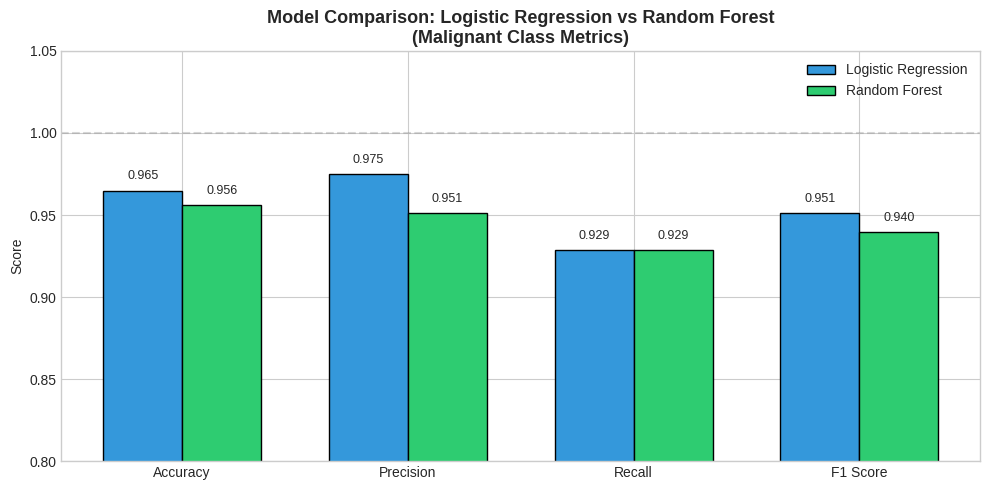

💡 Compare: Which model has better RECALL (sensitivity) for malignant tumors?
   In cancer screening, recall matters more than accuracy!


In [12]:
# ============================================================
# Section 4b: Performance Comparison Bar Chart
# ============================================================
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = {
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_lr, pos_label=0),
                  precision_score(y_test, y_pred_rf, pos_label=0)],
    'Recall': [recall_score(y_test, y_pred_lr, pos_label=0),
               recall_score(y_test, y_pred_rf, pos_label=0)],
    'F1 Score': [f1_score(y_test, y_pred_lr, pos_label=0),
                 f1_score(y_test, y_pred_rf, pos_label=0)],
}

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, [v[0] for v in metrics.values()], width,
               label='Logistic Regression', color='#3498DB', edgecolor='black')
bars2 = ax.bar(x + width/2, [v[1] for v in metrics.values()], width,
               label='Random Forest', color='#2ECC71', edgecolor='black')

ax.set_ylabel('Score')
ax.set_title('Model Comparison: Logistic Regression vs Random Forest\n(Malignant Class Metrics)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics.keys())
ax.legend()
ax.set_ylim(0.8, 1.05)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("💡 Compare: Which model has better RECALL (sensitivity) for malignant tumors?")
print("   In cancer screening, recall matters more than accuracy!")


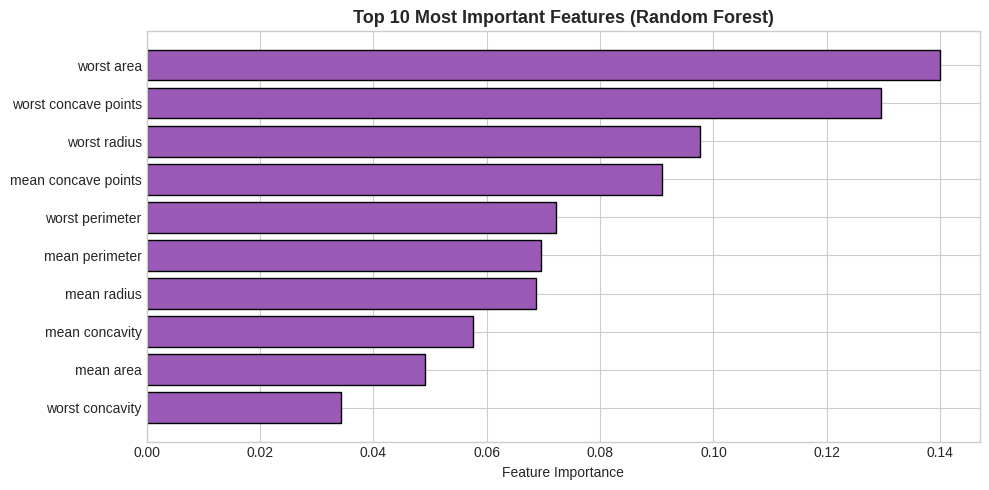

💡 The most important features align with what pathologists look for:
   → Larger, more irregular nuclei = higher chance of malignancy


In [13]:
# Feature importance from Random Forest
importances = model_rf.feature_importances_
indices = np.argsort(importances)[-10:]  # Top 10

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(10), importances[indices], color='#9B59B6', edgecolor='black')
ax.set_yticks(range(10))
ax.set_yticklabels(X.columns[indices])
ax.set_xlabel('Feature Importance')
ax.set_title('Top 10 Most Important Features (Random Forest)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 The most important features align with what pathologists look for:")
print("   → Larger, more irregular nuclei = higher chance of malignancy")


## 5. 🤖 AI-Assisted Coding with Gemini

Google Colab includes **Gemini AI** — think of it as a knowledgeable study partner who can explain concepts, generate code, and help you think through problems.

**Important:** Always verify Gemini's suggestions! AI assistants can make mistakes.

> **Note:** The `google.colab.ai` module is only available in the Colab environment. If running locally, skip this section.


In [14]:
# ============================================================
# Section 5: Gemini AI Integration
# ============================================================
try:
    from google.colab import ai

    # Prompt 1: Explain the confusion matrix clinically
    print("🤖 Gemini Prompt 1: Clinical interpretation")
    print("=" * 50)
    response = ai.generate_text(
        "I trained a logistic regression on the breast cancer Wisconsin dataset. "
        "Accuracy is 96% but recall for the malignant class is 93%. "
        "Explain what this means clinically and suggest 3 ways to improve recall."
    )
    print(response)

except ImportError:
    print("⚠️ google.colab.ai is not available in this environment.")
    print("   This section works only in Google Colab.")
    print("\n📝 Try these prompts manually in Colab's Gemini sidebar:")
    print('   1. "Explain this confusion matrix in clinical terms"')
    print('   2. "How can I improve recall to 98% for cancer detection?"')
    print('   3. "What features are most important for breast cancer classification?"')


🤖 Gemini Prompt 1: Clinical interpretation
This is a great scenario to discuss the nuances of model evaluation in a critical domain like healthcare.

Let's break down what your metrics mean clinically and then how to improve them.

---

### Clinical Meaning of Accuracy (96%) and Recall for Malignant Class (93%)

1.  **Overall Accuracy (96%)**:
    *   **Meaning:** Your model correctly identifies whether a tumor is benign or malignant 96% of the time, across all cases. This sounds very good on the surface.
    *   **Clinical Implication:** It suggests that the model is generally reliable. For every 100 predictions, it gets 96 right and 4 wrong. The 4 wrong predictions are a mix of:
        *   **False Negatives (FN):** Predicting benign when it's actually malignant.
        *   **False Positives (FP):** Predicting malignant when it's actually benign.

2.  **Recall for Malignant Class (93%)**:
    *   **Meaning:** Of all the *truly malignant* (cancerous) cases in your dataset, your model

In [15]:
# Prompt 2: Generate feature importance code
try:
    from google.colab import ai

    print("\n🤖 Gemini Prompt 2: Feature importance visualization")
    print("=" * 50)
    code = ai.generate_text(
        "Write Python code to plot SHAP values for a Random Forest trained "
        "on the breast cancer Wisconsin dataset from sklearn. Use a summary plot."
    )
    print(code)

except ImportError:
    print("⚠️ Gemini not available. Try in Colab!")
    print("\n💡 Manual alternative: Use the Random Forest feature_importances_ we already computed above.")



🤖 Gemini Prompt 2: Feature importance visualization
Okay, let's plot SHAP values using a summary plot for a Random Forest classifier trained on the breast cancer dataset.

First, ensure you have the necessary libraries installed:
```bash
pip install scikit-learn pandas shap matplotlib
```

Now, here's the Python code:

```python
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import shap
import matplotlib.pyplot as plt

# 1. Load the Breast Cancer Wisconsin dataset
breast_cancer = load_breast_cancer()
X = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
y = breast_cancer.target

# The target variable `y` is 0 for benign, 1 for malignant.
# We will typically explain the prediction of the positive class (malignant, class 1).

# 2. Split data into training and testing sets (good practice, though SHAP can be run on full data)


In [16]:
# Prompt 3: Challenge Gemini on a common misconception
try:
    from google.colab import ai

    print("\n🤖 Gemini Prompt 3: Challenge a misconception")
    print("=" * 50)
    response = ai.generate_text(
        "A hospital administrator says our breast cancer classifier has '96% accuracy' "
        "so it's ready for clinical deployment. Explain why they might be wrong, "
        "considering class imbalance, different clinical contexts (screening vs confirmation), "
        "and the difference between sensitivity and specificity."
    )
    print(response)

except ImportError:
    print("⚠️ Gemini not available. Try in Colab!")
    print("\n💡 Key insight: 96% accuracy means nothing if sensitivity for cancer is low.")
    print("   A model that always predicts 'benign' would get ~63% accuracy on this dataset!")



🤖 Gemini Prompt 3: Challenge a misconception
The administrator's excitement about "96% accuracy" for a breast cancer classifier is understandable, as it sounds very high. However, in a medical context, particularly for critical conditions like cancer, relying solely on overall accuracy can be dangerously misleading. Here's why they might be wrong, considering the factors you mentioned:

---

### 1. The Problem with Overall Accuracy in Imbalanced Datasets

Breast cancer is, thankfully, a relatively rare condition in the general population. This creates what's known as **class imbalance** in the data used to train and test the classifier.

*   **Example:** Imagine a screening population where only 1% of individuals actually have breast cancer.
    *   If a classifier simply predicted "no cancer" for *everyone*, it would achieve an accuracy of **99%** (correctly identifying 99 out of 100 people as cancer-free).
    *   However, this "99% accurate" classifier would be absolutely useless c

## 6. 📝 Student Tasks

Complete the following tasks to solidify your understanding. Work through them in order — each builds on the previous one.

| Task | Description | Difficulty |
|------|-------------|------------|
| 1 | Load dataset, print shape and first 5 feature names | ⭐ |
| 2 | Create correlation heatmap, identify top 5 features | ⭐ |
| 3 | Train logistic regression + confusion matrix | ⭐⭐ |
| 4 | Train Random Forest, compare with bar chart | ⭐⭐ |
| 5 | Use Gemini to suggest preprocessing, implement, evaluate | ⭐⭐⭐ |


In [ ]:
# ============================================================
# Task 1 (⭐): Load and explore the dataset
# ============================================================
# TODO: Your code here
# Hint: Use load_breast_cancer(), create a DataFrame,
#       print shape and first 5 feature names

# Expected output:
# Dataset shape: (569, 30)
# First 5 features: ['mean radius', 'mean texture', 'mean perimeter', ...]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='diagnosis')
print(data)


In [ ]:
# ============================================================
# Task 2 (⭐): Create correlation heatmap
# ============================================================
# TODO: Your code here
# Hint: Use sns.heatmap() with X.corr()
# Identify the top 5 features most correlated with the target




In [ ]:
# ============================================================
# Task 3 (⭐⭐): Train logistic regression classifier
# ============================================================
# TODO: Your code here
# Steps:
# 1. Split data with train_test_split (test_size=0.2)
# 2. Create and fit LogisticRegression
# 3. Predict on test set
# 4. Print accuracy and confusion matrix
# 5. Print classification_report




In [ ]:
# ============================================================
# Task 4 (⭐⭐): Train Random Forest and compare
# ============================================================
# TODO: Your code here
# Steps:
# 1. Train RandomForestClassifier(n_estimators=100)
# 2. Compute accuracy, precision, recall, F1 for both models
# 3. Create a side-by-side bar chart comparison
# Hint: Use the comparison code from Section 4 as reference




In [ ]:
# ============================================================
# Task 5 (⭐⭐⭐): Gemini-assisted preprocessing
# ============================================================
# TODO: Your code here
# Steps:
# 1. Ask Gemini: "Suggest a preprocessing pipeline for breast
#    cancer classification that could improve recall"
# 2. Implement Gemini's suggestion (e.g., StandardScaler, feature selection)
# 3. Retrain your model with preprocessing
# 4. Compare results before and after preprocessing
#
# If Gemini is not available, try StandardScaler:
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)




## 7. 🎁 Bonus: Gradient Descent from Scratch

This is an **optional** exercise connecting to the math foundations from the lecture (Part 3). We implement simple linear regression using gradient descent to predict systolic blood pressure from age.

**Clinical context:** Can we predict blood pressure trends from patient demographics?


In [ ]:
# ============================================================
# Section 7: Gradient Descent from Scratch
# ============================================================

# Synthetic patient data: predict systolic BP from age
np.random.seed(42)
ages = np.array([30, 35, 40, 45, 50, 55, 60, 65, 70, 75], dtype=float)
bp = np.array([118, 122, 128, 132, 135, 140, 145, 148, 155, 160], dtype=float)

# Normalize age for better convergence
ages_norm = (ages - ages.mean()) / ages.std()

# Initialize parameters
w = 0.0  # weight
b = 0.0  # bias
learning_rate = 0.05
n_epochs = 100
losses = []

# Gradient descent loop
for epoch in range(n_epochs):
    # Forward pass: predictions
    y_pred = w * ages_norm + b

    # Compute loss (Mean Squared Error)
    loss = np.mean((bp - y_pred) ** 2)
    losses.append(loss)

    # Compute gradients
    dw = -2 * np.mean((bp - y_pred) * ages_norm)
    db = -2 * np.mean(bp - y_pred)

    # Update parameters
    w -= learning_rate * dw
    b -= learning_rate * db

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}: Loss = {loss:.2f}, w = {w:.4f}, b = {b:.4f}")

print(f"\n✅ Final: Loss = {losses[-1]:.2f}, w = {w:.4f}, b = {b:.4f}")


Epoch   0: Loss = 19299.50, w = 1.3108, b = 13.8300
Epoch  20: Loss = 286.04, w = 11.6738, b = 123.1674
Epoch  40: Loss = 5.01, w = 12.9337, b = 136.4602
Epoch  60: Loss = 0.85, w = 13.0868, b = 138.0763
Epoch  80: Loss = 0.79, w = 13.1055, b = 138.2728

✅ Final: Loss = 0.79, w = 13.1077, b = 138.2963


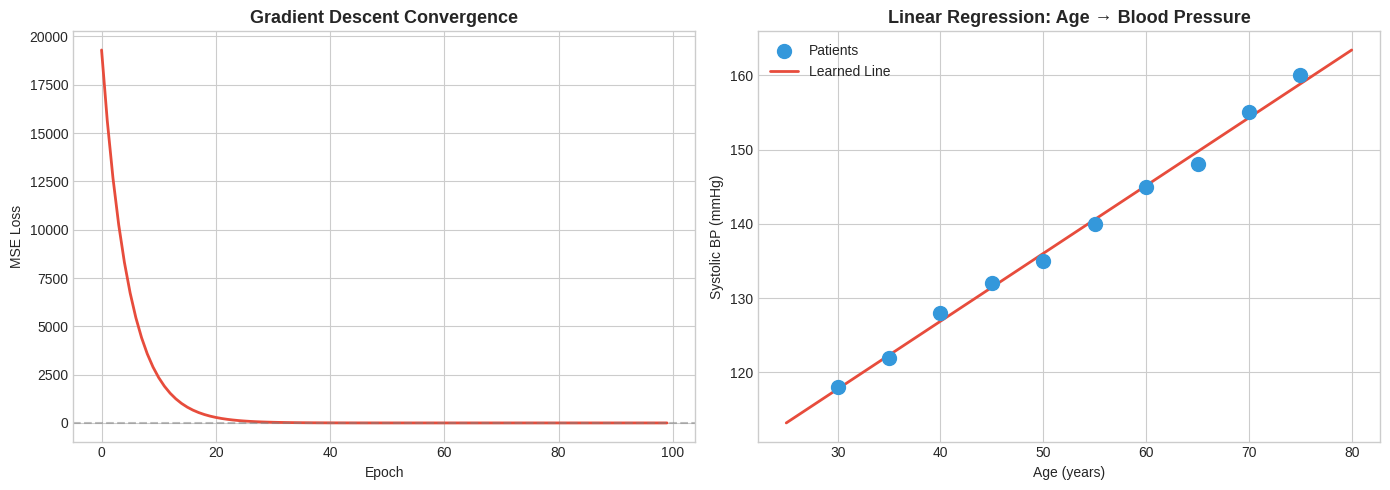

💡 Gradient descent found the best-fit line by iteratively reducing the loss.
   This is exactly how neural networks learn — just with more parameters!


In [ ]:
# Visualize gradient descent convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(losses, color='#E74C3C', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Gradient Descent Convergence', fontsize=13, fontweight='bold')
axes[0].axhline(y=losses[-1], color='gray', linestyle='--', alpha=0.5)

# Regression line
axes[1].scatter(ages, bp, color='#3498DB', s=100, zorder=5, label='Patients')
ages_pred = np.linspace(25, 80, 100)
ages_pred_norm = (ages_pred - ages.mean()) / ages.std()
bp_pred = w * ages_pred_norm + b
axes[1].plot(ages_pred, bp_pred, color='#E74C3C', linewidth=2, label='Learned Line')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Systolic BP (mmHg)')
axes[1].set_title('Linear Regression: Age → Blood Pressure', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print("💡 Gradient descent found the best-fit line by iteratively reducing the loss.")
print("   This is exactly how neural networks learn — just with more parameters!")


## 8. ✅ Summary & Self-Check

### Key Takeaways

1. **Digital Health** = mHealth + Wearables + EHR/FHIR + IoT + Clinical Decision Support
2. **AI ⊃ ML ⊃ DL ⊃ NN** — a nested hierarchy, not interchangeable terms
3. **Three ML paradigms**: supervised (labeled), unsupervised (discover), reinforcement (reward)
4. **ML Pipeline**: data → features → model → evaluation → deployment
5. **Evaluation metrics**: accuracy alone is dangerous — use sensitivity, specificity, F1, AUC
6. **Your first classifier**: logistic regression on breast cancer data (~96% accuracy)

### Self-Check Checklist

- [ ] I can define digital health and name its 4 technology domains
- [ ] I can distinguish AI, ML, DL, and Neural Networks
- [ ] I can explain what sensitivity and specificity mean clinically
- [ ] I trained a classifier and interpreted the confusion matrix
- [ ] I understand why "96% accuracy" can be misleading
- [ ] I used Gemini AI as a coding/learning assistant

### Next Week Preview
**Week 3: Deep Learning Fundamentals and Neural Network Basics**
- Today you chose features manually → next week: neural networks learn features automatically
- Perceptron → MLP, activation functions, backpropagation, Keras/PyTorch intro


In [ ]:
# Final verification: did everything run?
print("=" * 60)
print("🎉 Congratulations! You've completed Week 2 Notebook!")
print("=" * 60)
print(f"\n📊 Summary of your results:")
print(f"   Dataset: {X.shape[0]} patients, {X.shape[1]} features")
print(f"   Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"   Random Forest Accuracy:       {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"\n🔑 Remember: Accuracy isn't everything!")
print(f"   → For cancer screening: prioritize SENSITIVITY (recall)")
print(f"   → For confirmatory tests: prioritize SPECIFICITY")
print(f"\n📅 Next week: Deep Learning Fundamentals — neural networks")
print(f"   that learn features AUTOMATICALLY from raw data!")


🎉 Congratulations! You've completed Week 2 Notebook!

📊 Summary of your results:
   Dataset: 569 patients, 30 features
   Logistic Regression Accuracy: 0.965
   Random Forest Accuracy:       0.956

🔑 Remember: Accuracy isn't everything!
   → For cancer screening: prioritize SENSITIVITY (recall)
   → For confirmatory tests: prioritize SPECIFICITY

📅 Next week: Deep Learning Fundamentals — neural networks
   that learn features AUTOMATICALLY from raw data!
